# Fraud Detection Experiment

This notebook contains the process of exploring, preprocessing, and modeling credit card transaction data to detect fraudulent activities.

In [78]:
# Import necessary libraries for data processing and modeling
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

## 1. Load the Dataset
Loading the credit card transactions dataset.

In [2]:
# Load the dataset from raw data directory
df=pd.read_csv("../../data/raw/creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Data Preprocessing
Drop unnecessary columns like 'Time' that might not be useful for prediction.

In [4]:
# Drop Time column
df=df.drop('Time',axis=1)

In [5]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Feature Scaling
Apply logarithmic transformation and standard scaling to the 'Amount' feature to handle its skewed distribution.

In [9]:
# Log transform the 'Amount' column to handle skewness
df['Amount'] = np.log1p(df['Amount'])

# Scale the 'Amount' column using StandardScaler
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

In [10]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.124303,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-1.114639,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.682368,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.009339,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.670241,0


## 3. Train-Test Split
Split data into features (X) and target variable (y).

In [30]:
# Extract features and target variables
X=df.drop('Class',axis=1)
y=df['Class']

In [31]:
X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.124303
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-1.114639
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.682368
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.009339
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.670241


In [32]:
y

0         0
1         0
2         0
3         0
4         0
         ..
284802    0
284803    0
284804    0
284805    0
284806    0
Name: Class, Length: 284807, dtype: int64

In [33]:
# Split data into training and testing sets (80% train, 20% test)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [34]:
X_train.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
265518,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,-0.157403,...,-0.134435,0.076197,0.297537,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248,-0.623867
180305,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,0.284864,...,-0.227279,0.038628,0.228197,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002,-1.067456
42664,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,-2.009561,...,1.280856,-2.798352,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,1.218646
198723,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,1.756121,...,-0.490642,-0.139670,0.077013,0.208310,-0.538236,-0.278032,-0.162068,0.018045,-0.063005,-0.719583
82325,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,-0.558955,...,-0.275297,-0.243245,-0.173298,-0.006692,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194,0.793694


In [35]:
y_train.head()

265518    0
180305    0
42664     0
198723    0
82325     0
Name: Class, dtype: int64

In [36]:
y_train.value_counts()

Class
0    227451
1       394
Name: count, dtype: int64

In [37]:
y_test.value_counts()

Class
0    56864
1       98
Name: count, dtype: int64

In [38]:
a=98/56864
b=394/227451

In [39]:
a,b

(0.0017234102419808666, 0.0017322412299792043)

## 4. Modeling
### Logistic Regression (Baseline)

In [53]:
# Train baseline Logistic Regression model
log_reg_base=LogisticRegression(random_state=42)
log_reg_base.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [54]:
log_reg_base_preds=log_reg_base.predict(X_test)

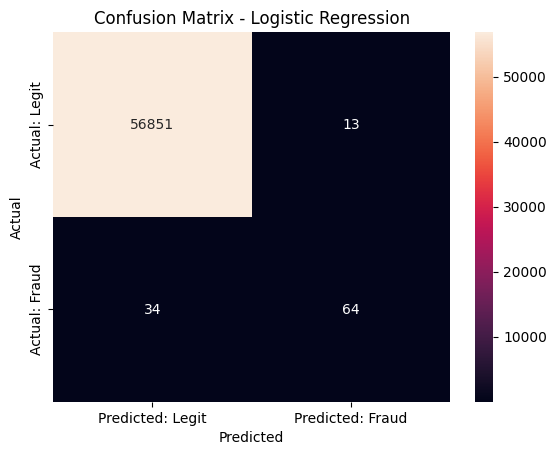

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, log_reg_base_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Predicted: Legit', 'Predicted: Fraud'],
            yticklabels=['Actual: Legit', 'Actual: Fraud'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')

plt.show()

In [56]:
print(classification_report(y_test, log_reg_base_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.65      0.73        98

    accuracy                           1.00     56962
   macro avg       0.92      0.83      0.87     56962
weighted avg       1.00      1.00      1.00     56962



### Logistic Regression with Balanced Weights

In [58]:
# Train Logistic Regression model with class weighting to handle imbalance
log_reg_balanced_wts = LogisticRegression(class_weight='balanced', random_state=42)

In [59]:
log_reg_balanced_wts.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [60]:
log_reg_balanced_wts_preds=log_reg_balanced_wts.predict(X_test)

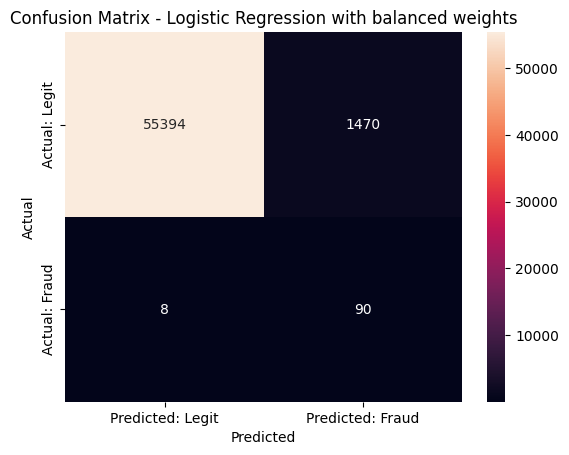

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, log_reg_balanced_wts_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Predicted: Legit', 'Predicted: Fraud'],
            yticklabels=['Actual: Legit', 'Actual: Fraud'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression with balanced weights')

plt.show()

In [62]:
print(classification_report(y_test, log_reg_balanced_wts_preds))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



### Random Forest (Baseline)

In [66]:
base_rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

base_rf.fit(X_train, y_train)
base_rf_preds = base_rf.predict(X_test)

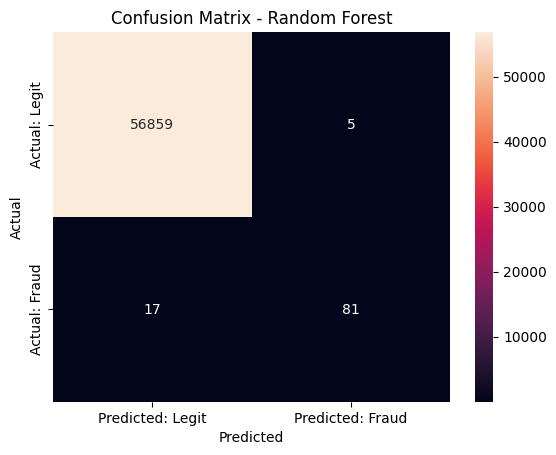

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, base_rf_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Predicted: Legit', 'Predicted: Fraud'],
            yticklabels=['Actual: Legit', 'Actual: Fraud'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')

plt.show()

In [92]:
print(classification_report(y_test, base_rf_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.83      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



### Random Forest with Balanced Weights

In [72]:
balanced_wts_rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_estimators=100
)

balanced_wts_rf.fit(X_train, y_train)
balanced_wts_rf_preds = balanced_wts_rf.predict(X_test)

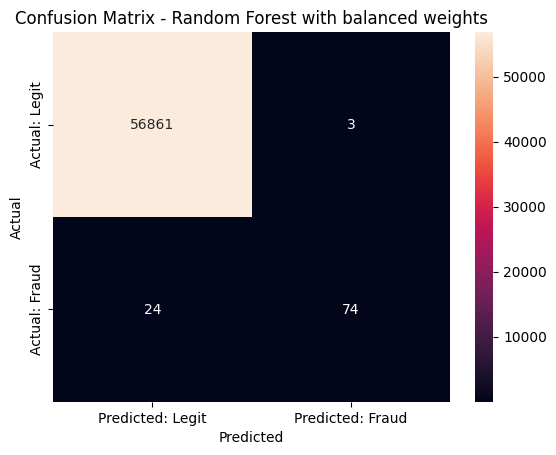

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, balanced_wts_rf_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Predicted: Legit', 'Predicted: Fraud'],
            yticklabels=['Actual: Legit', 'Actual: Fraud'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest with balanced weights')

plt.show()

In [75]:
print(classification_report(y_test, balanced_wts_rf_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962



### XGBoost (Baseline)

In [79]:
base_xgb = XGBClassifier(
    random_state=42,
    n_estimators=100
)

base_xgb.fit(X_train, y_train)
base_xgb_preds = base_xgb.predict(X_test)

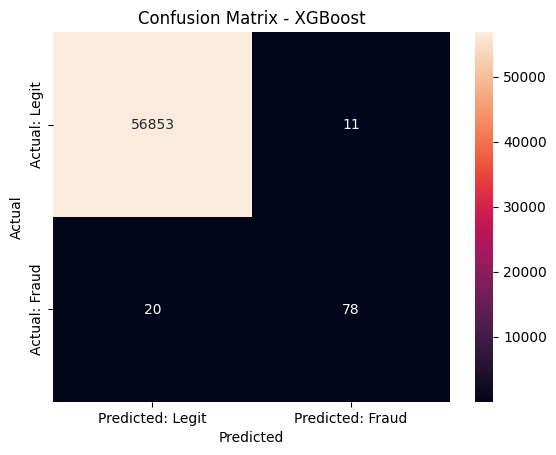

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, base_xgb_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Predicted: Legit', 'Predicted: Fraud'],
            yticklabels=['Actual: Legit', 'Actual: Fraud'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')

plt.show()

In [81]:
print(classification_report(y_test, base_xgb_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.80      0.83        98

    accuracy                           1.00     56962
   macro avg       0.94      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962



### XGBoost with Balanced Weights
Scale pos weight adjusts the penalty by the proportion of class ratios.

In [82]:
balanced_wts_xgb = XGBClassifier(
    scale_pos_weight = (len(y_train[y_train==0]) / len(y_train[y_train==1])),
    random_state=42,
    n_estimators=100
)

balanced_wts_xgb.fit(X_train, y_train)
balanced_wts_xgb_preds = balanced_wts_xgb.predict(X_test)

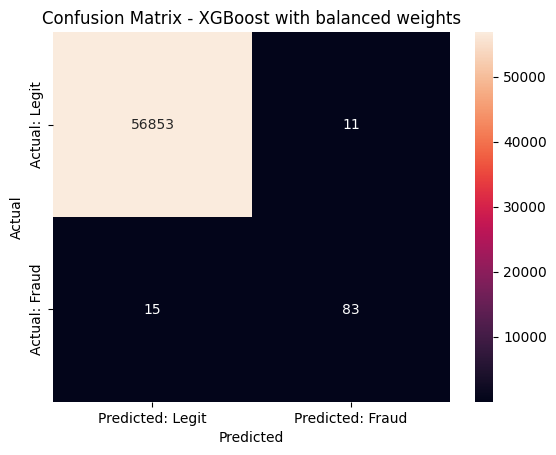

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, balanced_wts_xgb_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Predicted: Legit', 'Predicted: Fraud'],
            yticklabels=['Actual: Legit', 'Actual: Fraud'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost with balanced weights')

plt.show()

In [84]:
print(classification_report(y_test, balanced_wts_xgb_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



## 5. Model Evaluation on Training Data
Checking performance on the training set to identify overfitting.

In [85]:
log_reg_balanced_wts_train_preds=log_reg_balanced_wts.predict(X_train)

## 5. Model Evaluation on Training Data
Checking performance on the training set to identify overfitting.

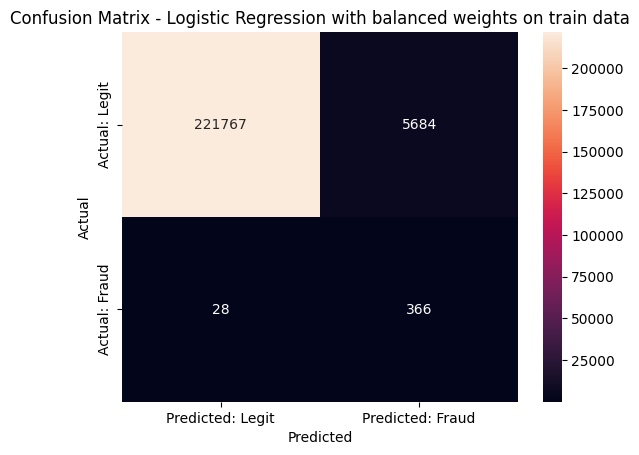

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train, log_reg_balanced_wts_train_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Predicted: Legit', 'Predicted: Fraud'],
            yticklabels=['Actual: Legit', 'Actual: Fraud'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression with balanced weights on train data')

plt.show()

In [98]:
base_rf_train_preds=base_rf.predict(X_train)

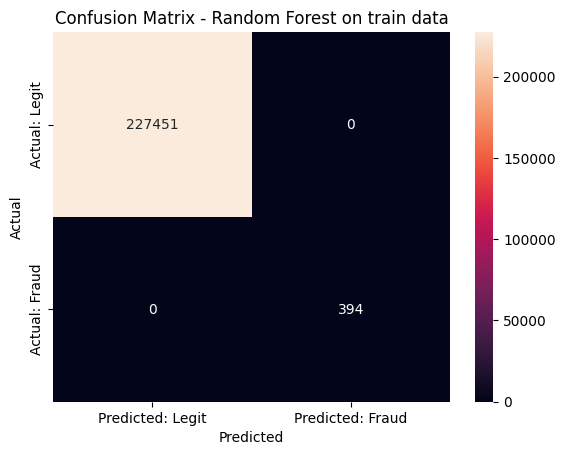

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train, base_rf_train_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Predicted: Legit', 'Predicted: Fraud'],
            yticklabels=['Actual: Legit', 'Actual: Fraud'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest on train data')

plt.show()

In [89]:
balanced_wts_xgb_train_preds=balanced_wts_xgb.predict(X_train)

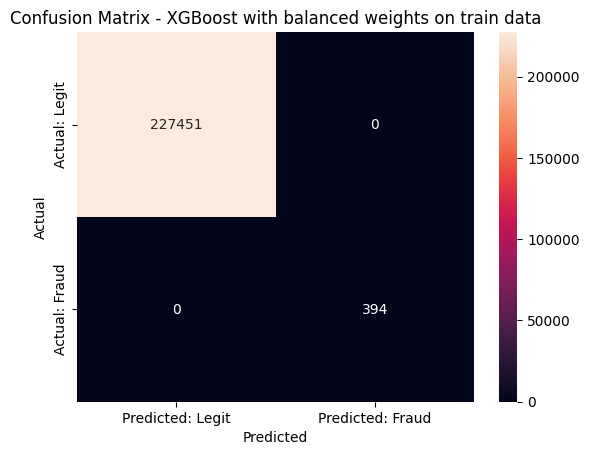

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train, balanced_wts_xgb_train_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Predicted: Legit', 'Predicted: Fraud'],
            yticklabels=['Actual: Legit', 'Actual: Fraud'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost with balanced weights on train data')

plt.show()

## 6. Threshold Optimization for XGBoost
Evaluating different classification thresholds to maximize recall for detecting fraud.

In [101]:
y_prob = balanced_wts_xgb.predict_proba(X_test)[:, 1]

In [102]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

for t in thresholds:
    y_pred = (y_prob > t).astype(int)
    
    print(f"\nThreshold: {t}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Threshold: 0.1
[[56843    21]
 [   14    84]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.80      0.86      0.83        98

    accuracy                           1.00     56962
   macro avg       0.90      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962


Threshold: 0.2
[[56850    14]
 [   14    84]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.86      0.86        98

    accuracy                           1.00     56962
   macro avg       0.93      0.93      0.93     56962
weighted avg       1.00      1.00      1.00     56962


Threshold: 0.3
[[56851    13]
 [   14    84]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.86      0.86        98

    accuracy                           1.

In [103]:
# Set best threshold found from the analysis
best_threshold = 0.3
y_final = (y_prob > best_threshold).astype(int)

In [104]:
y_final

array([0, 0, 0, ..., 0, 0, 0], shape=(56962,))

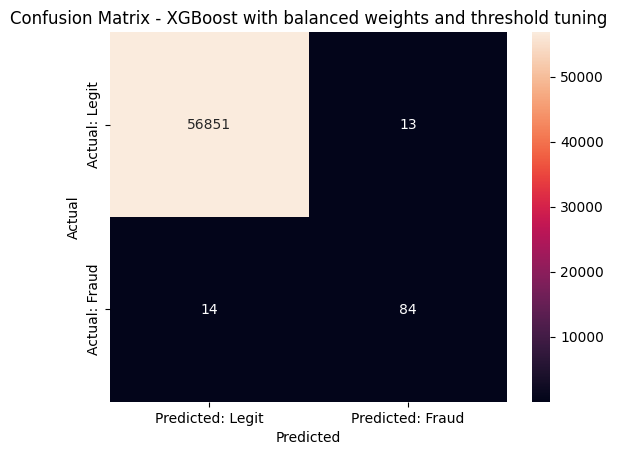

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_final)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Predicted: Legit', 'Predicted: Fraud'],
            yticklabels=['Actual: Legit', 'Actual: Fraud'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost with balanced weights and threshold tuning')

plt.show()

In [106]:
print(classification_report(y_test, y_final))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.86      0.86        98

    accuracy                           1.00     56962
   macro avg       0.93      0.93      0.93     56962
weighted avg       1.00      1.00      1.00     56962



## 7. Hyperparameter Tuning for XGBoost

In [107]:
params = {
    "max_depth": [3, 4, 5],
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
}

In [109]:
# Setup RandomizedSearchCV for hyperparameter tuning
# Optimizing for 'recall' to minimize false negatives
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

xgb = XGBClassifier(scale_pos_weight=(len(y_train[y_train==0]) / len(y_train[y_train==1])))

search = RandomizedSearchCV(
    xgb,
    param_distributions=params,
    n_iter=10,
    scoring="recall",   # IMPORTANT
    cv=3,
    verbose=1,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [119]:
y_preds_tuned=best_model.predict(X_test)

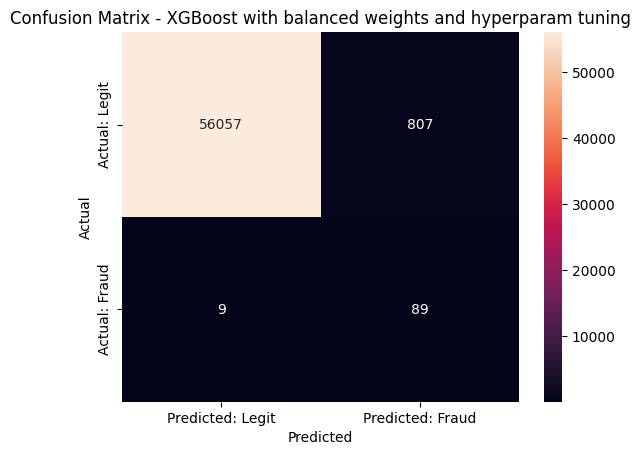

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_preds_tuned)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Predicted: Legit', 'Predicted: Fraud'],
            yticklabels=['Actual: Legit', 'Actual: Fraud'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost with balanced weights and hyperparam tuning')

plt.show()

In [122]:
xgb_logloss = XGBClassifier(
    scale_pos_weight=(len(y_train[y_train == 0]) / len(y_train[y_train == 1])),
    random_state=42,
    n_estimators=100,
    eval_metric="logloss"
)
xgb_logloss.fit(X_train,y_train)
xgb_logloss_preds=xgb_logloss.predict(X_test)

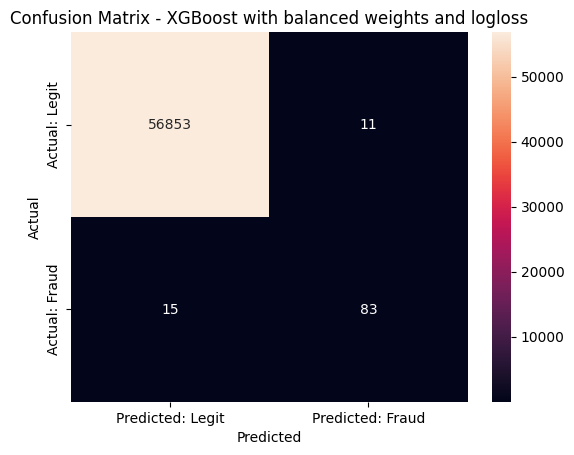

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, xgb_logloss_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Predicted: Legit', 'Predicted: Fraud'],
            yticklabels=['Actual: Legit', 'Actual: Fraud'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost with balanced weights and logloss')

plt.show()

In [125]:
print(classification_report(y_test, xgb_logloss_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [131]:
y_prob_logloss = xgb_logloss.predict_proba(X_test)[:, 1]

In [132]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

for t in thresholds:
    y_pred = (y_prob_logloss > t).astype(int)
    
    print(f"\nThreshold: {t}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Threshold: 0.1
[[56843    21]
 [   14    84]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.80      0.86      0.83        98

    accuracy                           1.00     56962
   macro avg       0.90      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962


Threshold: 0.2
[[56850    14]
 [   14    84]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.86      0.86        98

    accuracy                           1.00     56962
   macro avg       0.93      0.93      0.93     56962
weighted avg       1.00      1.00      1.00     56962


Threshold: 0.3
[[56851    13]
 [   14    84]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.86      0.86        98

    accuracy                           1.

In [139]:
# Set best threshold found from the analysis
best_threshold = 0.2
y_final_logloss = (y_prob_logloss > best_threshold).astype(int)

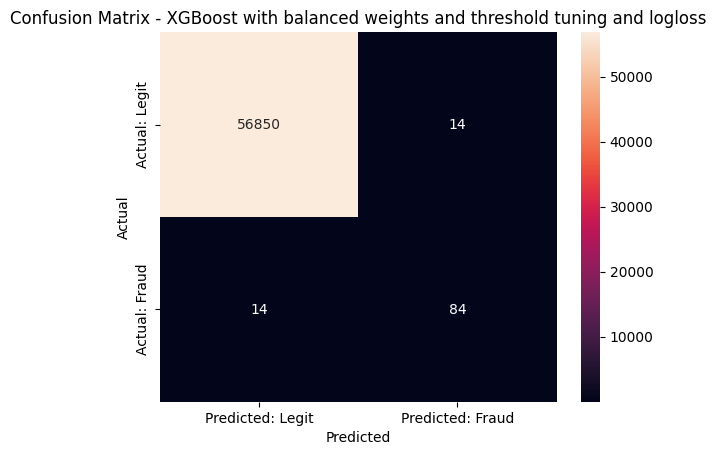

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_final_logloss)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Predicted: Legit', 'Predicted: Fraud'],
            yticklabels=['Actual: Legit', 'Actual: Fraud'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost with balanced weights and threshold tuning and logloss')

plt.show()

## 8. Final Decision
**Conclusion:** The final decision is to go with **XGBoost with balanced weights and threshold optimization**. This combination provides the best recall and robust performance in identifying fraudulent transactions, effectively minimizing false negatives which are critical in this domain.